# BEoRN: Post-processing N-body Simulation Data

This notebook demonstrates how to use **BEoRN** to model the 21-cm brightness temperature signal from the Epoch of Reionization (EoR) using an existing N-body simulation as input. BEoRN paints astrophysical radiation fields — X-ray heating, Lyman-alpha coupling, and ionization — onto the cosmological density field by placing pre-computed 1D profiles around dark matter halos.

The density fields and halo catalogs are read from a pre-run N-body simulation. The workflow is **N-body code agnostic**: BEoRN provides an abstract `NBodyLoader` base class that you subclass and fill in with format-specific reading logic. This notebook shows how to write such a loader using a **PKDGrav3** dataset as a concrete example. A production-ready `PKDGravLoader` is also available via `beorn.load_input_data` for PKDGrav3 users.

**Requirements:** Install BEoRN:
```bash
pip install git+https://github.com/cosmic-reionization/beorn.git
```

**Output:** All results are saved under `CACHE_ROOT` (set via the `SCRATCH` environment variable, defaulting to `./cache/`).

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [ ]:
# CACHE_ROOT: where intermediate results (radiation profiles) are stored.
# On a cluster set the SCRATCH environment variable to a fast scratch filesystem.
CACHE_ROOT = Path("cache")

# FILE_ROOT: root directory of the N-body simulation data.
# On a cluster set the PROJECT environment variable; locally it defaults to
# the "input/200Mpc" folder that ships with this repository.
import os
_project = os.getenv("PROJECT")
if _project is not None:
    FILE_ROOT = Path(_project) / "input" / "200Mpc" / "CDM_200Mpc_2048"
else:
    # default: data bundled alongside this notebook
    FILE_ROOT = Path("input") / "200Mpc"

# OUTPUT_ROOT: where painted 3D IGM grids are stored.
# Kept separate from CACHE_ROOT so profiles (reusable) and painted grids
# (parameter-specific) don't mix.
OUTPUT_ROOT = Path("output")

In [3]:
import beorn

import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.titlesize': 14,
})

INFO:numexpr.utils:NumExpr defaulting to 10 threads.


## 1. Set simulation and astrophysical parameters

Here we define the cosmology, the simulation volume, and the astrophysical source model.

- **Simulation grid** (`simulation`): box size and grid resolution must match the N-body data.
- **Solver** (`solver`): the redshift range over which the N-body snapshots are selected (given as `[z_min, z_max]`), and the halo mass bins that define the profile lookup table.
- **Cosmo-sim** (`cosmo_sim`): path to the N-body data directory.
- **Cosmology** (`cosmology`): standard ΛCDM parameters — must match those used in the N-body run.
- **Source model** (`source`): star formation efficiency, ionizing photon production, X-ray emission, and Lyman-alpha flux. These are the key parameters to vary.

> **Tip:** `solver.redshifts` for N-body inputs is a two-element list `[z_min, z_max]` that selects which on-disk snapshots to use. The loader reads all available snapshots in that range from disk.

In [ ]:
parameters = beorn.structs.Parameters()

## Simulation grid — must match the N-body data
# This dataset: 200 Mpc/h box, 256^3 density grids (nc256/)
# cores=1: custom loaders defined in the notebook cannot be pickled for
# multiprocessing workers (Python 'spawn' limitation on macOS/Windows).
# Move MyNBodyLoader to a separate .py file to use cores > 1.
parameters.simulation.cores = 1
parameters.simulation.Lbox  = 200       # comoving Mpc/h
parameters.simulation.Ncell = 256        # must match density file grid size

## Solver: profile integration grid and halo mass bins
# solver.redshifts defines the fine redshift grid used to integrate the 1D profiles.
# Its min/max also sets the z range used to filter which N-body snapshots are loaded.
parameters.solver.redshifts                 = np.arange(24, 5, -0.5)
parameters.solver.halo_mass_bin_min         = 1e7
parameters.solver.halo_mass_bin_max         = 1e15
parameters.solver.halo_mass_nbin            = 40
parameters.solver.halo_mass_accretion_alpha = np.array([0.785, 0.795])

## N-body data location
parameters.cosmo_sim.file_root = FILE_ROOT

## Cosmology (must match the N-body run — Planck 2015)
parameters.cosmology.Om = 0.315
parameters.cosmology.Ob = 0.049
parameters.cosmology.Ol = 1 - 0.315
parameters.cosmology.h  = 0.673

## Source parameters
# X-ray emission
parameters.source.energy_cutoff_min_xray = 500
parameters.source.energy_cutoff_max_xray = 10000
parameters.source.energy_min_sed_xray    = 200
parameters.source.energy_max_sed_xray    = 10000
parameters.source.alS_xray               = 1.5
parameters.source.xray_normalisation     = 0.3 * 3.4e40

# Lyman-alpha
parameters.source.n_lyman_alpha_photons = 9690
parameters.source.lyman_alpha_power_law = 0.0

# Ionization
parameters.source.Nion = 2000

# Escape fraction
parameters.source.f0_esc = 0.2
parameters.source.pl_esc = 0.5

# Star formation efficiency
parameters.source.f_st = 0.2
parameters.source.g1   = 0.49
parameters.source.g2   = -0.61
parameters.source.g3   = 4
parameters.source.g4   = -4
parameters.source.Mp   = 1.6e11 * parameters.cosmology.h
parameters.source.Mt   = 1e9

# Minimum star-forming halo mass
parameters.source.halo_mass_min = 1e8

### Source model visualization

Before running anything, it is useful to inspect the astrophysical source model implied by the parameters above. The two key efficiency functions are:

- **Star-formation efficiency** $f_*(M_h)$: fraction of accreted baryons converted into stars (double power-law with a low-mass suppression below $M_t$).
- **Escape fraction** $f_\mathrm{esc}(M_h)$: fraction of ionising photons that escape into the IGM (power-law in halo mass).

These two functions, multiplied together and by $N_\mathrm{ion}$, set the ionising emissivity of each halo.

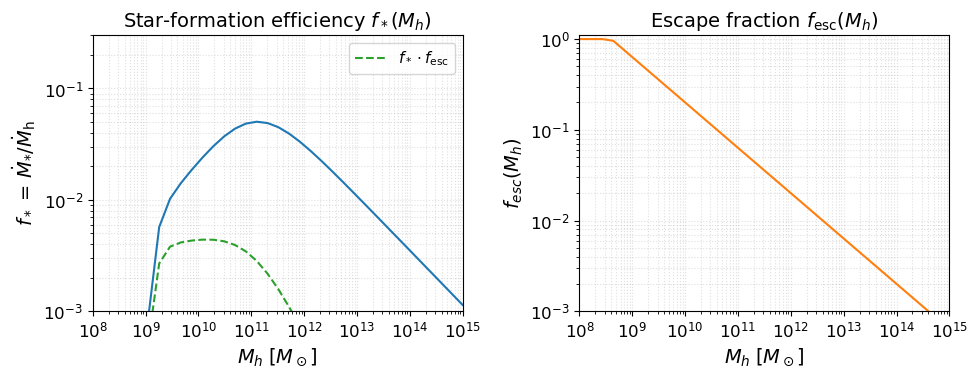

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

beorn.plotting.draw_star_formation_rate(axes[0], parameters, color='C0')
beorn.plotting.draw_f_esc(axes[1], parameters, color='C1')

# Overlay f_star * f_esc on the left panel
Mh_grid = parameters.solver.halo_mass_bins
keep = (Mh_grid > parameters.source.halo_mass_min) & (Mh_grid <= parameters.source.halo_mass_max)
Mh_plot = Mh_grid[keep]
from beorn.astro import f_star_Halo, f_esc as f_esc_func
combined = f_star_Halo(parameters, Mh_plot) * f_esc_func(parameters, Mh_plot)
axes[0].loglog(Mh_plot, combined, color='C2', ls='--', label=r'$f_* \cdot f_\mathrm{esc}$')
axes[0].legend(fontsize=11)

axes[0].set_title(r'Star-formation efficiency $f_*(M_h)$')
axes[1].set_title(r'Escape fraction $f_\mathrm{esc}(M_h)$')

for ax in axes:
    ax.set_xlabel(r'$M_h \; [M_\odot]$')
    ax.grid(True, which='both', ls=':', alpha=0.4)
    ax.set_xlim(1e8, 1e15)
axes[0].set_ylim(1e-3, 3e-1)
axes[1].set_ylim(1e-3, 1.1)

plt.tight_layout()
plt.show()

## 2. Precompute radiation profiles

BEoRN pre-computes 1D radial profiles of X-ray heating, Lyman-alpha flux, and ionization around halos of different masses. These profiles capture how radiation from the first galaxies affects the surrounding IGM as a function of distance. Pre-computing them once and caching the result means they can be reused efficiently when painting different realisations or astrophysical models.

> **Note:** This step depends only on the astrophysical parameters above — it does not require the N-body density field or halo catalogs. Run this first to check that the source model produces sensible profiles before loading large data files.

In [6]:
cache_handler = beorn.io.Handler(CACHE_ROOT)

# Profiles depend only on astrophysics, not on which N-body snapshots exist on disk.
# solver.redshifts is the fine integration grid; the actual snapshot redshifts
# from the N-body data are used later during painting.
solver = beorn.precomputation.RadiationProfileSolver(parameters, parameters.solver.redshifts)
profiles = solver.get_or_compute_profiles(cache_handler)

INFO:beorn.io.handler:Using persistence directory at cache
INFO:beorn.precomputation.solver:Loaded radiation profiles from cache (z=24.00→5.50, 38 steps).


### Inspecting the pre-computed 1D profiles

The figure below mirrors Figure 2 of [Schaeffer et al. 2023](https://arxiv.org/abs/2305.15466). Each panel corresponds to a selected halo mass bin and shows how the radial profile evolves with redshift (blue → red):

1. **Halo mass accretion history** — exponential MAR model (grey) vs. Behroozi et al. 2020 simulations (gold).
2. **Lyman-α flux profile** $\rho_\alpha(r)$ — sets the WF coupling $x_\alpha$.
3. **Kinetic temperature profile** $T_k(r)$ — driven by X-ray heating.
4. **Ionization fraction** $x_\mathrm{HII}(r)$ — sharp bubble front expanding with time.

Adjust `mass_index` and the redshift list to explore different halo masses.

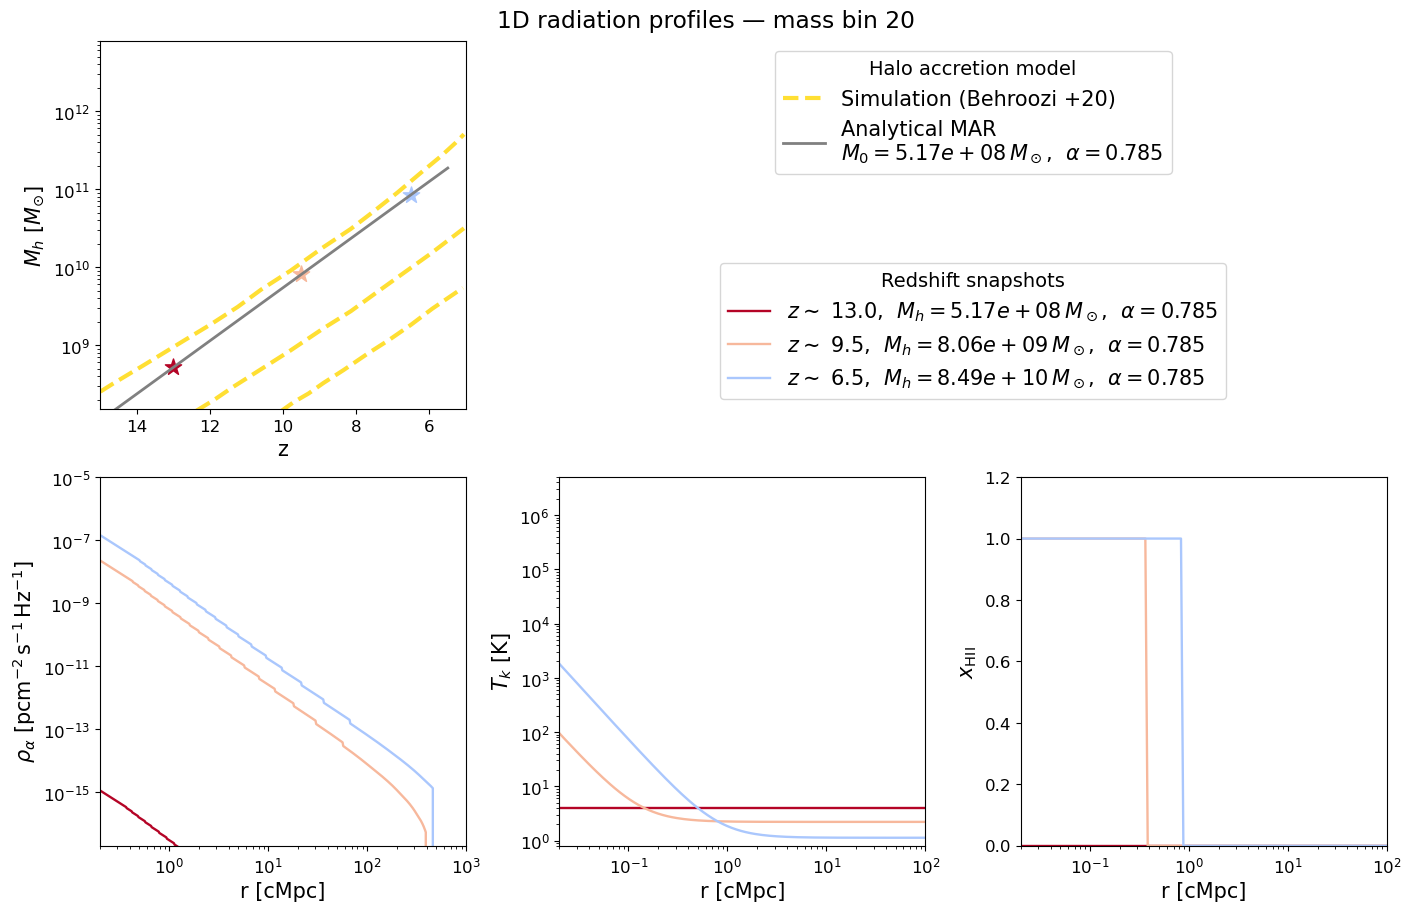

In [7]:
mass_index = parameters.solver.halo_mass_nbin // 2
profile_redshifts = [13.0, 9.5, 6.5]
# Use only the first alpha value to match the number of alpha bins in the cached profiles
profile_alphas = [parameters.solver.halo_mass_accretion_alpha[0]]

beorn.plotting.plot_1D_profiles(
    parameters,
    profiles,
    mass_index=mass_index,
    redshifts=profile_redshifts,
    alphas=profile_alphas,
    label=f"1D radiation profiles — mass bin {mass_index}",
    fontsize=15,
)

## 3. Write a data loader for your N-body format

BEoRN provides `NBodyLoader` as an abstract base class. To use your own N-body data you subclass it and fill in three methods:

| Method | What it does |
|---|---|
| `discover_snapshots()` | Scans the data directory and returns a list of `{redshift, density_file, halo_file}` dicts |
| `_read_density_file(path)` | Reads one density-grid file and returns a 3D overdensity array `δ = ρ/⟨ρ⟩ − 1` |
| `_read_halo_file(path)` | Reads one halo catalog and returns `(masses [M☉], positions [Mpc/h])` |

`discover_snapshots` is optional — you can skip it by passing your snapshot list directly via the `snapshots=` argument (see below).

The cell below shows a **complete example** using the PKDGrav3 dataset bundled with this tutorial. Adapt it to your own simulation by changing the file-reading logic.  If you are a PKDGrav3 user, note that `beorn.load_input_data.PKDGravLoader` is a production-ready implementation that does everything below (plus n_particles inference, multiple halo-finder glob patterns, and a descriptive log summary) — you can use it directly without defining a custom class.

In [8]:
class MyNBodyLoader(beorn.load_input_data.NBodyLoader):
    """Example N-body loader — adapt this template for your simulation format.

    Inherits all catalog management, partial-dataset handling, and z-range
    filtering from NBodyLoader.  You only need to implement the three methods
    below (or fewer if you use snapshots= to provide the list manually).
    """

    simulation_code = "MyNBodyCode"   # ← replace with your code name

    def __init__(
        self,
        parameters,
        log_filename="CDM_200Mpc_2048.log",   # ← log file that maps steps → redshifts
        density_subdir="nc256",               # ← subdirectory containing density grids
        halo_subdir="haloes",                 # ← subdirectory containing halo catalogs
        density_glob="*.den.256.0",           # ← glob pattern for density files
        halo_glob="*.fof.txt",                # ← glob pattern for halo catalog files
        **kwargs,                             # catalog_yml, snapshots, halo_finder, …
    ):
        self._log_filename = log_filename
        self._density_glob = density_glob
        self._halo_glob    = halo_glob
        file_root = Path(parameters.cosmo_sim.file_root)
        super().__init__(
            parameters,
            density_dir=file_root / density_subdir,
            halo_dir=file_root / halo_subdir,
            **kwargs,
        )

    # ── Step 1: discover which files exist and at what redshifts ─────────────
    def discover_snapshots(self):
        """Return [{redshift, density_file, halo_file}, …] for every snapshot found.

        Paths must be strings relative to self.file_root.
        Set halo_file to None when no catalog exists for that snapshot.

        Replace this method with whatever logic suits your data layout:
        read a CSV, parse a log file, query a database, return a hard-coded list, …
        """
        log_path = self.file_root / self._log_filename
        log_z = np.loadtxt(log_path)[:, 1]   # column 1 = redshift; row index = step − 1

        def _step(p):
            """Parse zero-padded step number from filename: prefix.STEP.suffix → int."""
            return int(p.name.split('.')[1])

        density_by_step = {_step(p): p for p in self.density_dir.glob(self._density_glob)}
        halo_by_step    = {_step(p): p for p in self.halo_dir.glob(self._halo_glob)}

        snapshots = []
        for step in sorted(density_by_step):
            row = step - 1
            if not (0 <= row < len(log_z)):
                continue
            halo_p = halo_by_step.get(step)
            snapshots.append({
                "redshift":     float(log_z[row]),
                "density_file": str(density_by_step[step].relative_to(self.file_root)),
                "halo_file":    str(halo_p.relative_to(self.file_root)) if halo_p else None,
            })
        return snapshots

    # ── Step 2: read a single density file ───────────────────────────────────
    def _read_density_file(self, path):
        """Read a flat binary float32 density grid → normalised overdensity δ = ρ/⟨ρ⟩ − 1.

        Replace this with your format (HDF5, FITS, netCDF, …).
        """
        Ncell = self.parameters.simulation.Ncell
        data = np.fromfile(path, dtype=np.float32).reshape(Ncell, Ncell, Ncell).T
        return data / np.mean(data, dtype=np.float64) - 1

    # ── Step 3: read a single halo catalog ───────────────────────────────────
    def _read_halo_file(self, path):
        """Read a 4-column (mass_Msol/h, x, y, z) text catalog.

        Must return:
          masses    — 1D array of halo masses in M☉
          positions — (N, 3) array of comoving positions in Mpc/h

        Replace this with your catalog format.
        """
        data = np.loadtxt(path)
        if data.ndim == 1:           # single-halo catalog
            data = data[np.newaxis, :]
        masses    = data[:, 0] * self.parameters.cosmology.h    # Msol/h → Msol
        positions = data[:, 1:] + self.parameters.simulation.Lbox / 2   # shift origin
        return masses, positions

### Instantiation options

Three ways to create the loader — choose whichever fits your workflow:

**Option A — auto-discover, no caching** (default): calls `discover_snapshots()` every run.

**Option B — auto-discover + cache to YML**: writes a snapshot catalog on the first run, reads it back on subsequent runs (fast). Use this when discovery is slow (large directories, slow filesystems).

**Option C — manual snapshot list**: skip `discover_snapshots()` entirely and supply the list directly. Useful when the log file is unavailable, the directory layout is non-standard, or you simply want full control over which snapshots are used.

In [9]:
# ── Option A: auto-discover snapshots from disk, no caching ──────────────────
# discover_snapshots() is called every time this cell runs.
loader = MyNBodyLoader(parameters, log_filename="CDM_200Mpc_2048.log")

# ── Option B: auto-discover + save/load a YML catalog ────────────────────────
# First run: scans disk and writes the YML.
# Subsequent runs: reads the YML — no directory scan needed.
#
# loader = MyNBodyLoader(
#     parameters,
#     log_filename="CDM_200Mpc_2048.log",
#     catalog_yml=FILE_ROOT / "my_catalog.yml",
# )

# ── Option C: skip discovery, provide the snapshot list manually ──────────────
# discover_snapshots() is never called.  Combine with catalog_yml= to persist.
#
# loader = MyNBodyLoader(
#     parameters,
#     log_filename="CDM_200Mpc_2048.log",  # unused when snapshots= is given
#     snapshots=[
#         {
#             "redshift":     11.265,
#             "density_file": "nc256/CDM_200Mpc_2048.00050.den.256.0",
#             "halo_file":    "haloes/CDM_200Mpc_2048.00050.fof.txt",
#         },
#         {
#             "redshift":      6.784,
#             "density_file": "nc256/CDM_200Mpc_2048.00090.den.256.0",
#             "halo_file":    "haloes/CDM_200Mpc_2048.00090.fof.txt",
#         },
#     ],
# )

# ── PKDGrav3 users: a production-ready loader already exists ──────────────────
# beorn ships PKDGravLoader which handles all of the above plus n_particles
# inference, AHF / Rockstar glob patterns, and a descriptive log summary:
#
#   loader = beorn.load_input_data.PKDGravLoader(parameters)

print(f"Found {loader.redshifts.size} snapshots: "
      f"z = {loader.redshifts.max():.1f} → {loader.redshifts.min():.1f}")

INFO:beorn.load_input_data.nbody_base:Snapshots discovered from disk (no catalog_yml provided — results are not cached). Pass catalog_yml='path/to/catalog.yml' to save the snapshot list for future runs.


Found 83 snapshots: z = 23.8 → 5.5


## 4. Inspect the halo catalog and density field

Before running the full simulation, it is useful to check the input data. The halo mass function should match the analytical prediction (Sheth & Tormen 1999) for the given cosmology and redshift. We also show a 2D slice through the matter overdensity field to confirm the density data looks sensible.

In [ ]:
# Find all snapshots that have a halo catalog
halo_indices = [i for i, c in enumerate(loader.catalogs) if c is not None]
print(f"Snapshots with halo catalogs ({len(halo_indices)} found):")
for i in halo_indices:
    print(f"  z = {loader.redshifts[i]:.3f}  (index {i})")

# Pick one to inspect — change z_target to any redshift listed above
z_target = loader.redshifts[halo_indices[-1]]   # lowest-z snapshot with halos
z_index  = halo_indices[np.argmin(np.abs(loader.redshifts[halo_indices] - z_target))]
z_actual = loader.redshifts[z_index]
print(f"\nInspecting z = {z_actual:.3f}  (index {z_index})")

halo_catalog = loader.load_halo_catalog(z_index)
print(f"Number of halos: {len(halo_catalog.masses)}")
if len(halo_catalog.masses) > 0:
    print(f"Mass range: {halo_catalog.masses.min():.2e} — {halo_catalog.masses.max():.2e} Msol")

# Halo mass function with analytical Sheth & Tormen (1999) reference
fig, ax = plt.subplots()
beorn.plotting.plot_halo_mass_function(ax, halo_catalog, bin_count=15,
                                       label=f'PKDGrav3  z={z_actual:.1f}',
                                       analytical_model='ST')
ax.set_title(f'Halo Mass Function at z={z_actual:.1f}', fontsize=14)
ax.legend()
plt.show()

In [ ]:
delta_m = loader.load_density_field(z_index)

Lbox = parameters.simulation.Lbox  # cMpc/h
extent = [0, Lbox, 0, Lbox]

plt.figure()
plt.imshow(delta_m[:, delta_m.shape[1] // 2, :], origin='lower',
           cmap='RdBu_r', extent=extent)
plt.colorbar(label=r'$\delta_\mathrm{m}$')
plt.xlabel('[cMpc/h]')
plt.ylabel('[cMpc/h]')
plt.title(f'Matter overdensity at z={z_actual:.1f}')
plt.show()

## 5. Paint the 3D signal maps

BEoRN places the pre-computed profiles around each halo in the catalog and accumulates their contributions on the grid. This produces 3D maps of the ionization fraction, gas temperature, and Lyman-alpha coupling at each redshift — the ingredients needed to compute the 21-cm brightness temperature.

Use `redshift_subset` to restrict painting to specific epochs. This is particularly useful when halo catalogs are only available at a few snapshots: painting all N-body snapshots at other redshifts would produce empty grids and waste disk space.

Snapshots that have already been computed are skipped automatically, so interrupted runs resume from where they left off.

In [19]:
output_handler = beorn.io.Handler(OUTPUT_ROOT, input_tag=loader.input_tag)

p = beorn.painting.PaintingCoordinator(
    parameters,
    loader=loader,
    output_handler=output_handler,
)

# redshift_subset: paint only these redshifts (nearest snapshot is used for each).
# Pass None (or omit) to paint all snapshots known to the loader.
# With sparse halo catalogs it is wasteful to paint every density snapshot —
# focus on the epochs where halos exist to save time and disk space.
painting_redshifts = [11.3, 7.0]   # ← adjust to match your available halo catalogs

multi_z_quantities = p.paint_full(profiles, redshift_subset=painting_redshifts)

INFO:beorn.io.handler:Using persistence directory at cache/output
INFO:beorn.painting.coordinator:redshift_subset: painting 2 of 83 available snapshot(s).
INFO:beorn.painting.coordinator:============================================================
BEoRN model summary
  Cosmology   : Om=0.315, Ob=0.049, h=0.673, sigma_8=0.83
  Grid        : Ncell=256, Lbox=200 Mpc/h
  Profile z   : z=24.0 -> 5.5 (38 steps)
  1D RT bins  : 1.0e+07 - 1.0e+15 Msun at z=5.5 (40 bins, traced back via exp. accretion)
  Source      : f_st=0.05, Nion=300, f0_esc=0.2
  X-ray       : norm=3.40e+39, E=[500, 10000] eV
  Lyman-alpha : n_phot=9690, star-forming above 1.0e+08 Msun
  Beorn hash  : 94fc089c
INFO:beorn.painting.coordinator:Setting up 1 painting processes for MPI.
INFO:beorn.painting.coordinator:Submitting 2/83 snapshot(s) to MPI workers.
INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.
INFO:beorn.painting.coordinator:Painting 4554001 halos at zgrid=11.5

OSError: Unable to synchronously create file (unable to truncate a file which is already open)

## 6. Visualise the 3D maps at a single redshift

We show a 2D slice through the simulation box for the three key fields at the chosen redshift: the ionization fraction $x_\mathrm{HII}$, the gas kinetic temperature $T_k$, and the 21-cm brightness temperature $\delta T_b$. The ionized bubbles visible in the $x_\mathrm{HII}$ map are driven by the same halos that appear in the mass function above.

In [ ]:
# Use a redshift with a halo catalog for a non-trivial signal map.
# z_actual and z_index are set in the inspect cell above.
snap = multi_z_quantities.snapshot(z_actual)

xHII_grid = snap.Grid_xHII[:]
dTb_grid  = snap.Grid_dTb
Tk_grid   = snap.Grid_Temp[:]

mid = xHII_grid.shape[1] // 2
Lbox = parameters.simulation.Lbox
extent = [0, Lbox, 0, Lbox]

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
for ax, grid, label in zip(axs,
                            [xHII_grid, Tk_grid, dTb_grid],
                            [r'\mathrm{HII}$', r'$ [K]', r'$\delta T_b$ [mK]']):
    im = ax.imshow(grid[:, mid, :], origin='lower', cmap='viridis', extent=extent)
    ax.set_xlabel('[cMpc/h]', fontsize=15)
    fig.colorbar(im, ax=ax, label=label)
axs[0].set_ylabel('[cMpc/h]', fontsize=15)
fig.suptitle(f'z={snap.z:.3f}', fontsize=15)
plt.tight_layout()
plt.show()

## 7. Global history and power spectra

The global (volume-averaged) signal summarises the overall evolution of reionization. We show the redshift evolution of the mean brightness temperature, gas temperature, and ionization fraction, as well as the 21-cm power spectrum amplitude at a fixed wavenumber $k$. These are the primary observational targets of radio telescopes such as SKA, HERA, and MWA.

> **Memory note:** The `draw_*` plotting functions use `global_mean()` internally, which iterates snapshots one at a time so peak memory is one 3D grid. The power spectrum panel requires `Grid_dTb` across all $z$ and will load all base fields.

In [ ]:
# fig = plt.figure(constrained_layout=True, figsize=(18, 6))
# gs = gridspec.GridSpec(2, 3, figure=fig)
# ax1 = fig.add_subplot(gs[:, 0])
# ax2 = fig.add_subplot(gs[0, 1])
# ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
# ax4 = fig.add_subplot(gs[:, 2])
#
# beorn.plotting.draw_dTb_signal(ax1, multi_z_quantities, color='k', lw=3)
# beorn.plotting.draw_Temp_signal(ax2, multi_z_quantities, color='k', lw=3)
# beorn.plotting.draw_xHII_signal(ax3, multi_z_quantities, color='k', lw=3)
# kplot = beorn.plotting.draw_dTb_power_spectrum_of_z(
#                     ax4, multi_z_quantities, parameters, k_value=0.1, color='k', lw=3)
# ax4.plot([], [], color='k', label=f'k={kplot:.2f} Mpc$^{{-1}}$')
# ax4.legend(loc=0)
# ax2.axes.get_xaxis().set_visible(False)
# plt.show()

## 8. Lightcone

A lightcone stitches together slices from different redshifts to mimic an actual observation: as we observe further into the past, the signal evolves. This is what a radio telescope effectively measures along the line of sight. The horizontal axis shows increasing redshift (earlier cosmic times) from right to left.

In [ ]:
# lightcone = beorn.structs.Lightcone.build(
#     parameters,
#     multi_z_quantities,
#     quantity="Grid_dTb",
# )
#
# fig, ax = plt.subplots(figsize=(18, 6))
# beorn.plotting.plot_lightcone(lightcone, ax, "", slice_number=30)
# fig.show()